# Category Performance Analysis

## 목적

전체 12개월의 상품 카테고리별 Item Sales 규모를 비교하고,
월별 KPI 분석에서 확인된 2017년 11월 증가와
2017년 12월 감소에 어떤 카테고리가 기여했는지 분석한다.

## 핵심 질문

1. Item Sales 규모가 가장 큰 카테고리는 무엇인가?
2. 전체 Item Sales 중 상위 카테고리의 비중은 얼마인가?
3. 성장률이 높지만 규모가 작은 카테고리는 존재하는가?
4. 2017년 11월 증가액을 주도한 카테고리는 무엇인가?
5. 2017년 12월 감소액이 큰 카테고리는 무엇인가?

In [1]:
from pathlib import Path

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = Path.cwd().parent

database_path = (
    project_root
    / "data"
    / "processed"
    / "olist.db"
)

report_dir = (
    project_root
    / "reports"
)

figure_dir = (
    report_dir
    / "figures"
)

connection = sqlite3.connect(
    database_path
)

In [3]:
# 전체 카테고리 성과
category_performance_df = pd.read_sql_query(
    """
    SELECT
        coalesce(
            product_category,
            'unknown'
        ) AS product_category,

        sum(
            item_price
        ) AS item_sales,

        count(*) AS item_row_count,

        count(
            DISTINCT product_id
        ) AS product_count,

        count(
            DISTINCT order_id
        ) AS order_count,

        count(
            DISTINCT customer_unique_id
        ) AS buyer_count

    FROM analysis_order_items

    GROUP BY
        coalesce(
            product_category,
            'unknown'
        )

    ORDER BY
        item_sales DESC
    """,
    connection
)

print(
    category_performance_df.head(10)
)

        product_category  item_sales  item_row_count  product_count  \
0          health_beauty   986035.80            7600           2012   
1          watches_gifts   962328.05            5016           1097   
2         bed_bath_table   768510.95            8387           2483   
3         sports_leisure   736116.07            6432           2284   
4  computers_accessories   673424.32            5974           1315   
5        furniture_decor   535378.59            5914           1858   
6             housewares   486807.08            5147           1901   
7                   auto   452590.91            3358           1634   
8             cool_stuff   402851.63            2449            564   
9                   toys   348730.34            2947           1113   

   order_count  buyer_count  
0         6928         6833  
1         4708         4645  
2         7022         6865  
3         5771         5650  
4         5116         5020  
5         4523         4441  
6       

In [4]:
# 판매 비중
total_item_sales = (
    category_performance_df["item_sales"]
    .sum()
)

category_performance_df[
    "item_sales_share"
] = (
    category_performance_df["item_sales"]
    / total_item_sales
)

In [5]:
print(
    category_performance_df[
        [
            "product_category",
            "item_sales",
            "item_sales_share",
            "order_count",
            "buyer_count",
            "product_count"
        ]
    ]
    .head(10)
)

        product_category  item_sales  item_sales_share  order_count  \
0          health_beauty   986035.80          0.096788         6928   
1          watches_gifts   962328.05          0.094461         4708   
2         bed_bath_table   768510.95          0.075436         7022   
3         sports_leisure   736116.07          0.072256         5771   
4  computers_accessories   673424.32          0.066103         5116   
5        furniture_decor   535378.59          0.052552         4523   
6             housewares   486807.08          0.047784         4344   
7                   auto   452590.91          0.044426         3125   
8             cool_stuff   402851.63          0.039543         2346   
9                   toys   348730.34          0.034231         2771   

   buyer_count  product_count  
0         6833           2012  
1         4645           1097  
2         6865           2483  
3         5650           2284  
4         5020           1315  
5         4441           1

In [6]:
# 판매된 고유 상품당 Item Sales
category_performance_df[
    "item_sales_per_product"
] = (
    category_performance_df["item_sales"]
    / category_performance_df["product_count"]
)

print(category_performance_df.head(10))

        product_category  item_sales  item_row_count  product_count  \
0          health_beauty   986035.80            7600           2012   
1          watches_gifts   962328.05            5016           1097   
2         bed_bath_table   768510.95            8387           2483   
3         sports_leisure   736116.07            6432           2284   
4  computers_accessories   673424.32            5974           1315   
5        furniture_decor   535378.59            5914           1858   
6             housewares   486807.08            5147           1901   
7                   auto   452590.91            3358           1634   
8             cool_stuff   402851.63            2449            564   
9                   toys   348730.34            2947           1113   

   order_count  buyer_count  item_sales_share  item_sales_per_product  
0         6928         6833          0.096788              490.077435  
1         4708         4645          0.094461              877.236144  
2 

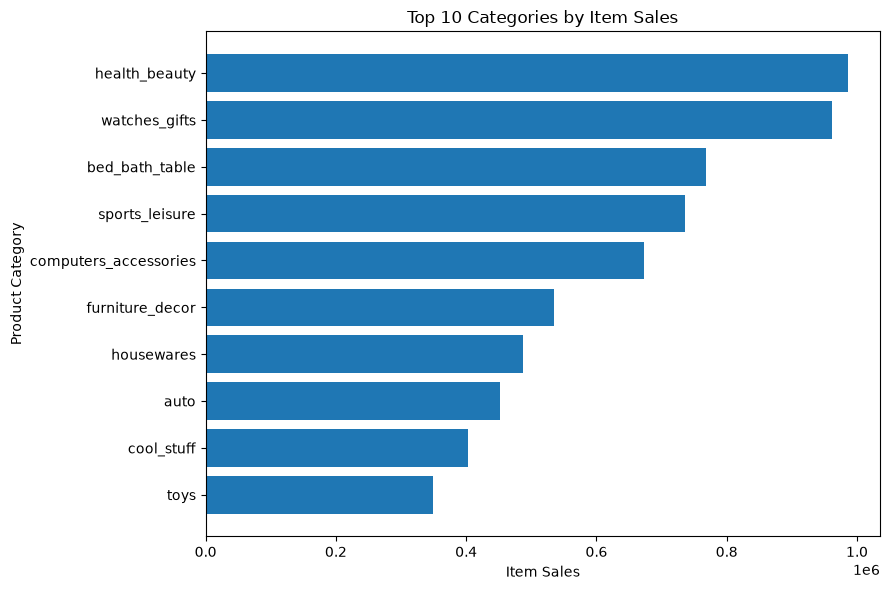

In [7]:
# Top 10 카테고리 그래프
top_category_df = (
    category_performance_df
    .head(10)
    .sort_values(
        "item_sales"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_category_df["product_category"],
    top_category_df["item_sales"]
)

plt.title(
    "Top 10 Categories by Item Sales"
)

plt.xlabel(
    "Item Sales"
)

plt.ylabel(
    "Product Category"
)

plt.tight_layout()

plt.savefig(
    figure_dir
    / "top_category_item_sales.png",
    dpi=150
)

plt.show()

In [8]:
# 2017년 11월 카테고리별 Item Sales 변화

november_growth_df = pd.read_sql_query(
    """
    SELECT
        coalesce(
            product_category,
            'unknown'
        ) AS product_category,

        sum(
            CASE
                WHEN order_month = '2017-10'
                THEN item_price
                ELSE 0
            END
        ) AS october_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_price
                ELSE 0
            END
        ) AS november_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_price
                ELSE 0
            END
        )
        -
        sum(
            CASE
                WHEN order_month = '2017-10'
                THEN item_price
                ELSE 0
            END
        ) AS item_sales_change

    FROM analysis_order_items

    WHERE
        order_month IN (
            '2017-10',
            '2017-11'
        )

    GROUP BY
        coalesce(
            product_category,
            'unknown'
        )

    ORDER BY
        item_sales_change DESC
    """,
    connection
)

print(
    november_growth_df.head(10)
)


        product_category  october_item_sales  november_item_sales  \
0         bed_bath_table            46007.70             87957.63   
1          health_beauty            40698.99             78274.40   
2        furniture_decor            30009.74             62091.27   
3          watches_gifts            64874.63             95292.34   
4                   toys            33324.42             62611.26   
5  computers_accessories            42009.38             69676.32   
6           garden_tools            25798.75             44275.18   
7             housewares            15883.68             33872.42   
8              perfumery            16877.82             31612.13   
9         sports_leisure            48568.98             62686.24   

   item_sales_change  
0           41949.93  
1           37575.41  
2           32081.53  
3           30417.71  
4           29286.84  
5           27666.94  
6           18476.43  
7           17988.74  
8           14734.31  
9         

In [9]:
# 2017년 12월 카테고리별 Item Sales 변화

december_decline_df = pd.read_sql_query(
    """
    SELECT
        coalesce(
            product_category,
            'unknown'
        ) AS product_category,

        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_price
                ELSE 0
            END
        ) AS november_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-12'
                THEN item_price
                ELSE 0
            END
        ) AS december_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-12'
                THEN item_price
                ELSE 0
            END
        )
        -
        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_price
                ELSE 0
            END
        ) AS item_sales_change

    FROM analysis_order_items

    WHERE
        order_month IN (
            '2017-11',
            '2017-12'
        )

    GROUP BY
        coalesce(
            product_category,
            'unknown'
        )

    ORDER BY
        item_sales_change
    """,
    connection
)

print(
    december_decline_df.head(10)
)

             product_category  november_item_sales  december_item_sales  \
0              bed_bath_table             87957.63             50081.16   
1       computers_accessories             69676.32             37428.67   
2             furniture_decor             62091.27             31073.09   
3               watches_gifts             95292.34             69556.92   
4                  cool_stuff             55696.66             37515.57   
5               health_beauty             78274.40             60688.75   
6                garden_tools             44275.18             26795.69   
7                   telephony             26117.63             12780.44   
8            office_furniture             17919.20              6684.37   
9  agro_industry_and_commerce             13932.49              5291.70   

   item_sales_change  
0          -37876.47  
1          -32247.65  
2          -31018.18  
3          -25735.42  
4          -18181.09  
5          -17585.65  
6          -1

In [10]:
# 전체 월 증감액과 검산
november_total_change = (
    987765.37
    - 648247.65
)

december_total_change = (
    726033.19
    - 987765.37
)

print(
    november_total_change
)

print(
    december_total_change
)

339517.72
-261732.18000000005


In [11]:
# 카테고리 증감 합과 검산
november_category_change = (
    november_growth_df[
        "item_sales_change"
    ]
    .sum()
)

print(
    november_category_change
)

december_category_change = (
    december_decline_df[
        "item_sales_change"
    ]
    .sum()
)

print(
    december_category_change
)

339517.72000000003
-261732.17999999996


In [12]:
# 기여도 계산
## 11월
november_growth_df[
    "change_contribution"
] = (
    november_growth_df[
        "item_sales_change"
    ]
    / november_category_change
)

## 12월
december_decline_df[
    "change_contribution"
] = (
    december_decline_df[
        "item_sales_change"
    ]
    / december_category_change
)

print(
    november_growth_df[
        [
            "product_category",
            "change_contribution"
        ]
    ]
    .head(10)
)

print(
    december_decline_df[
        [
            "product_category",
            "change_contribution"
        ]
    ]
    .head(10)
)

        product_category  change_contribution
0         bed_bath_table             0.123557
1          health_beauty             0.110673
2        furniture_decor             0.094491
3          watches_gifts             0.089591
4                   toys             0.086260
5  computers_accessories             0.081489
6           garden_tools             0.054420
7             housewares             0.052983
8              perfumery             0.043398
9         sports_leisure             0.041580
             product_category  change_contribution
0              bed_bath_table             0.144715
1       computers_accessories             0.123209
2             furniture_decor             0.118511
3               watches_gifts             0.098327
4                  cool_stuff             0.069464
5               health_beauty             0.067189
6                garden_tools             0.066784
7                   telephony             0.050957
8            office_furniture      

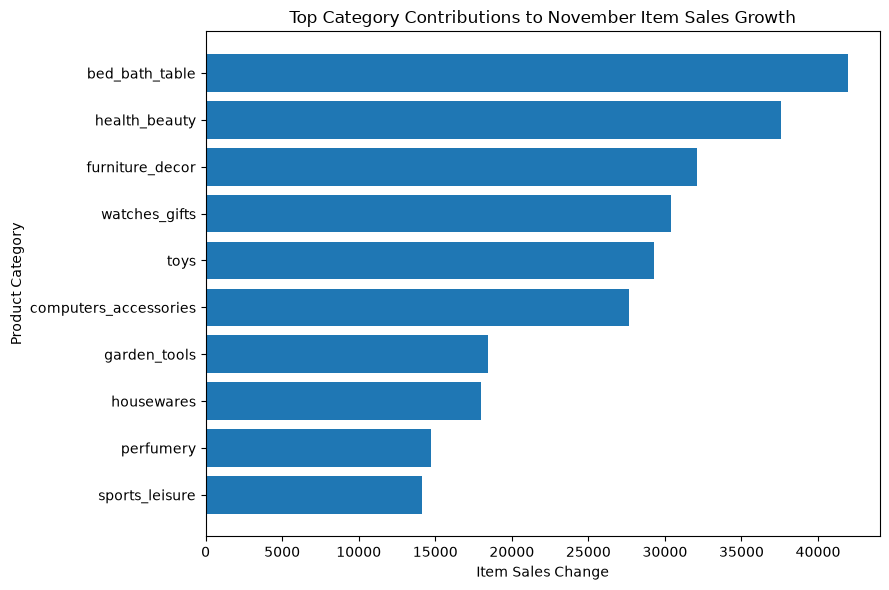

In [13]:
# 11월 증가 기여도 그래프
november_top_df = (
    november_growth_df
    .sort_values(
        "item_sales_change",
        ascending=False
    )
    .head(10)
    .sort_values(
        "item_sales_change"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    november_top_df["product_category"],
    november_top_df["item_sales_change"]
)

plt.title(
    "Top Category Contributions to November Item Sales Growth"
)

plt.xlabel(
    "Item Sales Change"
)

plt.ylabel(
    "Product Category"
)

plt.tight_layout()

plt.savefig(
    figure_dir
    / "category_sales_change_contribution.png",
    dpi=150
)

plt.show()

In [14]:
# CSV 저장용 숫자 정리

november_growth_df[
    "october_item_sales"
] = (
    november_growth_df[
        "october_item_sales"
    ]
    .round(2)
)

november_growth_df[
    "november_item_sales"
] = (
    november_growth_df[
        "november_item_sales"
    ]
    .round(2)
)

november_growth_df[
    "item_sales_change"
] = (
    november_growth_df[
        "item_sales_change"
    ]
    .round(2)
)

november_growth_df[
    "change_contribution"
] = (
    november_growth_df[
        "change_contribution"
    ]
    .round(4)
)

In [15]:
december_decline_df[
    "november_item_sales"
] = (
    december_decline_df[
        "november_item_sales"
    ]
    .round(2)
)

december_decline_df[
    "december_item_sales"
] = (
    december_decline_df[
        "december_item_sales"
    ]
    .round(2)
)

december_decline_df[
    "item_sales_change"
] = (
    december_decline_df[
        "item_sales_change"
    ]
    .round(2)
)

december_decline_df[
    "change_contribution"
] = (
    december_decline_df[
        "change_contribution"
    ]
    .round(4)
)

In [16]:
category_performance_df.to_csv(
    report_dir
    / "category_performance.csv",
    index=False
)

november_growth_df.to_csv(
    report_dir
    / "november_category_change.csv",
    index=False
)

december_decline_df.to_csv(
    report_dir
    / "december_category_change.csv",
    index=False
)

In [17]:
connection.close()